In [1]:
from hullwhite import GeneratePathsHWAndAssetEuler, P0T, PriceEuropeanOptionHWMC
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

## Cálculo de Delta mediante diferencias finitas

$$
\Delta = \frac{\partial V}{\partial S_0}
$$

Delta mide cuánto varía el precio de la opción cuando el precio inicial del activo tiene una pequeña variación.

Usando diferencias finitas centradas:

$$
\Delta \approx \frac{V(S_0+h)-V(S_0-h)}{2h}
$$

donde $h$ es una perturbación del precio inicial del activo.


Además, para reducir la varianza del estimador Monte Carlo, se utilizan los mismos números aleatorios en las dos valoraciones correspondientes a $S_0+h$ y $S_0-h$. Esta técnica, *common random numbers*, permite aislar mejor el efecto de la perturbación en $S_0$ y obtener una estimación más estable de la sensibilidad.

In [2]:
def DeltaFD_HW_MC(NoOfPaths, NoOfSteps, T, P0T, lambd, eta, S0, sigma_S, rho, K,
                  h=0.5, option_type="call", seed=123):
    """
    Calcula Delta por diferencias finitas centradas
    en el modelo Hull–White + activo, usando common random numbers.

    Parámetros
    ----------
    h
    seed : Para reutilizar los mismos números aleatorios
        en las simulaciones con S0+h y S0-h.
    """

    # Precio con S0 + h
    paths_up = GeneratePathsHWAndAssetEuler(
        NoOfPaths=NoOfPaths,
        NoOfSteps=NoOfSteps,
        T=T,
        P0T=P0T,
        lambd=lambd,
        eta=eta,
        S0=S0 + h,
        sigma_S=sigma_S,
        rho=rho,
        seed=seed
    )

    price_up, _ = PriceEuropeanOptionHWMC(
        paths=paths_up,
        K=K,
        T=T,
        option_type=option_type
    )

    # Precio con S0 - h
    paths_down = GeneratePathsHWAndAssetEuler(
        NoOfPaths=NoOfPaths,
        NoOfSteps=NoOfSteps,
        T=T,
        P0T=P0T,
        lambd=lambd,
        eta=eta,
        S0=S0 - h,
        sigma_S=sigma_S,
        rho=rho,
        seed=seed
    )

    price_down, _ = PriceEuropeanOptionHWMC(
        paths=paths_down,
        K=K,
        T=T,
        option_type=option_type
    )

    delta_fd = (price_up - price_down) / (2.0 * h)

    return delta_fd, price_up, price_down

In [3]:
# Parámetros del modelo
NoOfPaths = 20000
NoOfSteps = 250
T = 1.0

lambd = 0.5
eta = 0.01

# Parámetros del activo
S0 = 100.0
sigma_S = 0.20
rho = -0.3

# Parámetros de la opción
K = 100.0
option_type = "call"

# Tamaño de perturbación
h = 0.5

delta_fd, price_up, price_down = DeltaFD_HW_MC(
    NoOfPaths=NoOfPaths,
    NoOfSteps=NoOfSteps,
    T=T,
    P0T=P0T,
    lambd=lambd,
    eta=eta,
    S0=S0,
    sigma_S=sigma_S,
    rho=rho,
    K=K,
    h=h,
    option_type=option_type,
    seed=123
)

print(f"Precio con S0 + h = {price_up:.6f}")
print(f"Precio con S0 - h = {price_down:.6f}")
print(f"Delta FD          = {delta_fd:.6f}")

Precio con S0 + h = 10.704435
Precio con S0 - h = 10.068360
Delta FD          = 0.636076


##### Resultado numérico para la Delta por diferencias finitas

El valor obtenido para la Delta es positivo, esto indica que un aumento en el precio inicial del activo incrementa el valor de la opción.

Una Delta próxima a $0.64$ indica que, para pequeñas variaciones del activo subyacente, el precio de la opción cambia en aproximadamente un 64% de dicha variación.

La utilización de diferencias centradas y de la técnica de *common random numbers* permite obtener una estimación más estable y con menor ruido Monte Carlo.

#### Sensibilidad de la Delta respecto al tamaño de la perturbación $h$

En el método de diferencias finitas, la estimación de la Delta depende del tamaño de la perturbación utilizada en el precio inicial del activo.

La elección de $h$ no es arbitraria. Si $h$ es demasiado grande, la aproximación puede introducir un sesgo apreciable, por el contrario, si $h$ es demasiado pequeño, la diferencia entre $V(S_0+h)$ y $V(S_0-h)$ puede ser mínima por el ruido estadístico inherente al método Monte Carlo.

Vamos a analizar la sensibilidad de la Delta estimada respecto al parámetro $h$. Este estudio permite evaluar la estabilidad numérica del método de diferencias finitas y elegir un valor de perturbación razonable para los cálculos posteriores.

In [4]:
h_values = [2.0, 1.0, 0.5, 0.2, 0.1, 0.05]

delta_results = []

for h in h_values:
    delta_fd, price_up, price_down = DeltaFD_HW_MC(
        NoOfPaths=20000,
        NoOfSteps=250,
        T=1.0,
        P0T=P0T,
        lambd=0.5,
        eta=0.01,
        S0=100.0,
        sigma_S=0.20,
        rho=-0.3,
        K=100.0,
        h=h,
        option_type="call",
        seed=123
    )

    delta_results.append((h, price_up, price_down, delta_fd))

In [5]:
for h, price_up, price_down, delta_fd in delta_results:
    print(f"h = {h:>4} | V(S0+h) = {price_up:.6f} | V(S0-h) = {price_down:.6f} | Delta FD = {delta_fd:.6f}")

h =  2.0 | V(S0+h) = 11.691162 | V(S0-h) = 9.150305 | Delta FD = 0.635214
h =  1.0 | V(S0+h) = 11.029087 | V(S0-h) = 9.757309 | Delta FD = 0.635889
h =  0.5 | V(S0+h) = 10.704435 | V(S0-h) = 10.068360 | Delta FD = 0.636076
h =  0.2 | V(S0+h) = 10.511778 | V(S0-h) = 10.257241 | Delta FD = 0.636341
h =  0.1 | V(S0+h) = 10.447889 | V(S0-h) = 10.320600 | Delta FD = 0.636447
h = 0.05 | V(S0+h) = 10.415998 | V(S0-h) = 10.352350 | Delta FD = 0.636472


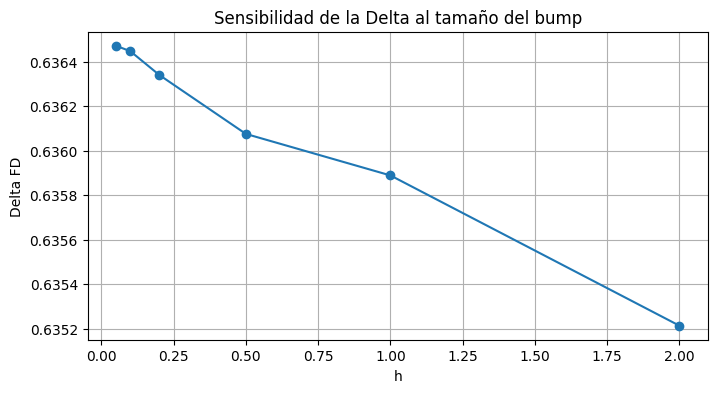

In [6]:
h_plot = [row[0] for row in delta_results]
delta_plot = [row[3] for row in delta_results]

plt.figure(figsize=(8, 4))
plt.plot(h_plot, delta_plot, marker='o')
plt.xlabel("h")
plt.ylabel("Delta FD")
plt.title("Sensibilidad de la Delta al tamaño del bump")
plt.grid(True)
plt.show()

#### Interpretación del análisis de sensibilidad respecto a $h$

Los resultados obtenidos muestran bastante estabilidad de la Delta estimada al cambiar el tamaño de la perturbación $h$.

En el rango analizado, la Delta permanece próxima a $0.636$, con variaciones muy pequeñas incluso al modificar significativamente el valor de h.

- la relación entre el precio de la opción y el valor inicial del activo es suficientemente suave;
- la aproximación mediante diferencias finitas centradas es robusta;
- el uso de *common random numbers* ha contribuido a reducir el ruido estadístico del estimador Monte Carlo.

No se observan señales de inestabilidad ni para valores relativamente grandes de $h$ ni para valores pequeños dentro del rango considerado. En consecuencia, puede seleccionarse un valor intermedio, como $h=0.5$.

## Cálculo de Delta mediante pathwise
Partimos de la expresión de valoración de una call europea en el modelo con tipos de interés estocásticos:

$$
V_0 = \mathbb{E}^{\mathbb{Q}}\left[e^{-\int_0^T r_t\,dt}(S_T-K)^+\right]
$$
Con Pathwise tenemos que

$$
\Delta = \frac{\partial V_0}{\partial S_0}
=
\mathbb{E}^{\mathbb{Q}}
\left[
\frac{\partial}{\partial S_0}
\left(
e^{-\int_0^T r_t\,dt}(S_T-K)^+
\right)
\right]
$$

En este modelo, el factor de descuento depende de la trayectoria del tipo corto, pero no depende de $S_0$. Por tanto, al derivar respecto al precio inicial del activo, el descuento es un factor multiplicativo constante para cada trayectoria.

Además, el activo simulado mediante el esquema log-Euler implica que $S_T$ es proporcional a $S_0$. En consecuencia:

$$
\frac{\partial S_T}{\partial S_0} = \frac{S_T}{S_0}
$$

La derivada del payoff respecto a $S_T$ es:

$$
\frac{\partial}{\partial S_T}(S_T-K)^+ = \mathbf{1}_{\{S_T>K\}}
$$

Si aplicamos la regla de la cadena, obtenemos:

$$
\frac{\partial}{\partial S_0}(S_T-K)^+
=
\mathbf{1}_{\{S_T>K\}}
\frac{\partial S_T}{\partial S_0}
$$

y, por tanto, la Delta pathwise queda dada por:

$$
\Delta_{\text{PW}}
=
\mathbb{E}^{\mathbb{Q}}
\left[
e^{-\int_0^T r_t\,dt}
\mathbf{1}_{\{S_T>K\}}
\frac{S_T}{S_0}
\right]
$$

Esto nos permite construir un estimador Monte Carlo directo sin necesidad de recalcular el precio para valores perturbados de $S_0$, como en el método de diferencias finitas.

In [7]:
def DeltaPathwise_HW_MC(paths, S0, K, T, option_type):
    """
    Calcula la Delta mediante el método pathwise
    en el modelo conjunto Hull–White + activo.

    Parámetros
    ----------
    paths : Diccionario con:
        - "R": trayectorias del short rate
        - "S": trayectorias del activo
    S0 : Precio inicial del activo.
    K : Strike.
    T : Vencimiento.
    option_type : "call" o "put".

    Devuelve
    --------
    delta_pw : Estimación pathwise de la Delta.
    stderr : Error estándar del estimador pathwise.
    """

    R = paths["R"]
    S = paths["S"]

    NoOfSteps = R.shape[1] - 1
    dt = T / NoOfSteps

    # Integral del short rate para el descuento
    integral_r = np.sum(R[:, :-1] * dt, axis=1)
    discount = np.exp(-integral_r)

    ST = S[:, -1]

    option_type = option_type.lower()

    if option_type == "call":
        indicator = (ST > K).astype(float)
        pathwise_samples = discount * indicator * (ST / S0)

    elif option_type == "put":
        indicator = (ST < K).astype(float)
        pathwise_samples = -discount * indicator * (ST / S0)

    else:
        raise ValueError("option_type debe ser 'call' o 'put'.")

    delta_pw = np.mean(pathwise_samples)
    stderr = np.std(pathwise_samples, ddof=1) / np.sqrt(len(pathwise_samples))

    return delta_pw, stderr

In [9]:
paths_joint = GeneratePathsHWAndAssetEuler(
    NoOfPaths=20000,
    NoOfSteps=250,
    T=1.0,
    P0T=P0T,
    lambd=0.5,
    eta=0.01,
    S0=100.0,
    sigma_S=0.20,
    rho=-0.3,
    seed=123
)

# Delta pathwise
delta_pw, stderr_pw = DeltaPathwise_HW_MC(
    paths=paths_joint,
    S0=100.0,
    K=100.0,
    T=1.0,
    option_type="call"
)

print(f"Delta Pathwise = {delta_pw:.6f}")
print(f"Error estándar = {stderr_pw:.6f}")

Delta Pathwise = 0.636452
Error estándar = 0.004076


In [10]:
print(f"Delta FD       = {delta_fd:.6f}")
print(f"Delta Pathwise = {delta_pw:.6f}")
print(f"Diferencia     = {abs(delta_fd - delta_pw):.6f}")

Delta FD       = 0.636472
Delta Pathwise = 0.636452
Diferencia     = 0.000020


#### Comparación entre Delta por diferencias finitas y Delta pathwise

Se observa que ambas estimaciones son prácticamente idénticas. La diferencia entre ellas es muy pequeña, lo que indica una elevada consistencia entre el método de diferencias finitas y el método pathwise en este problema.

Este resultado confirma que la implementación de ambos enfoques es correcta y que la sensibilidad de primer orden respecto al precio inicial del activo está siendo capturada de forma fiable en el modelo con tipos de interés estocásticos.

El método pathwise muestra un comportamiento muy satisfactorio en este contexto. Delta es una sensibilidad de primer orden y la derivada de $S_T$ respecto a $S_0$ tiene una forma muy sencilla.

Por tanto, para el cálculo de la Delta en este modelo, el método pathwise es una alternativa atractiva frente a diferencias finitas, al evitar recalcular el precio con perturbaciones sobre $S_0$ y proporcionar una estimación muy consistente con la obtenida por FD.